# 05. Классификация: IC50 > медианы

В данном ноутбуке решается задача бинарной классификации.

Цель работы — определить, превышает ли значение `IC50, mM` медианное значение выборки.

Для решения задачи будут подготовлены данные, обучены несколько моделей классификации, выполнено сравнение качества моделей и сделан вывод о применимости разных подходов.

In [1]:
# 1. Импорт библиотек

# Импортируем pandas для работы с табличными данными
import pandas as pd

# Импортируем numpy для численных расчётов
import numpy as np

# Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем StandardScaler для стандартизации признаков
from sklearn.preprocessing import StandardScaler

# Импортируем логистическую регрессию для задачи классификации
from sklearn.linear_model import LogisticRegression

# Импортируем случайный лес для задачи классификации
from sklearn.ensemble import RandomForestClassifier

# Импортируем градиентный бустинг для задачи классификации
from sklearn.ensemble import GradientBoostingClassifier

# Импортируем метрики качества классификации
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Импортируем confusion_matrix для анализа ошибок классификации
from sklearn.metrics import confusion_matrix, classification_report

# Импортируем GridSearchCV для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Импортируем warnings, чтобы убрать лишние предупреждения
import warnings

# Отключаем предупреждения для более аккуратного вывода
warnings.filterwarnings('ignore')

In [2]:
# 2. Загрузка обработанного датасета

# Импортируем files из Google Colab для загрузки файла с компьютера
from google.colab import files

# Загружаем обработанный CSV-файл, который был сохранён после EDA
uploaded = files.upload()

Saving processed_chemical_data.csv to processed_chemical_data.csv


In [3]:
# 3. Чтение обработанного датасета

# Считываем обработанный CSV-файл в переменную df
df = pd.read_csv('processed_chemical_data.csv')

# Проверяем, есть ли в датасете технический столбец с индексом
if 'Unnamed: 0' in df.columns:

    # Удаляем технический столбец, так как он не является химическим признаком
    df = df.drop(columns=['Unnamed: 0'])

# Выводим первые 5 строк, чтобы проверить корректность загрузки
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 4. Создание целевой переменной для классификации

# Создаём список исходных целевых переменных
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

# Считаем медианное значение IC50
ic50_median = df['IC50, mM'].median()

# Создаём бинарную целевую переменную: 1, если IC50 больше медианы, иначе 0
df['IC50_above_median'] = (df['IC50, mM'] > ic50_median).astype(int)

# Выводим медианное значение IC50
print('Медиана IC50:', ic50_median)

# Проверяем распределение классов
df['IC50_above_median'].value_counts()

Медиана IC50: 46.58518345980803


,count
IC50_above_median,
0,501
1,500


In [5]:
# 5. Подготовка признаков и целевой переменной

# Формируем матрицу признаков X: удаляем исходные целевые переменные и новый классификационный таргет
X = df.drop(columns=target_columns + ['IC50_above_median'])

# Формируем целевую переменную y для классификации
y = df['IC50_above_median']

# Проверяем размерность матрицы признаков
print('Размер X:', X.shape)

# Проверяем размерность целевой переменной
print('Размер y:', y.shape)

Размер X: (1001, 210)
Размер y: (1001,)


In [6]:
# 6. Разделение данных на обучающую и тестовую выборки

# Делим данные на обучающую и тестовую выборки с сохранением баланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Выводим размер обучающей выборки
print('Размер X_train:', X_train.shape)

# Выводим размер тестовой выборки
print('Размер X_test:', X_test.shape)

# Проверяем распределение классов в обучающей выборке
print('Классы в y_train:')
print(y_train.value_counts())

# Проверяем распределение классов в тестовой выборке
print('Классы в y_test:')
print(y_test.value_counts())

Размер X_train: (800, 210)
Размер X_test: (201, 210)
Классы в y_train:
IC50_above_median
1    400
0    400
Name: count, dtype: int64
Классы в y_test:
IC50_above_median
0    101
1    100
Name: count, dtype: int64


In [7]:
# 7. Стандартизация признаков

# Создаём объект StandardScaler для приведения признаков к единому масштабу
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке и сразу преобразуем X_train
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовую выборку с помощью scaler, обученного на X_train
X_test_scaled = scaler.transform(X_test)

# Проверяем размерность стандартизированной обучающей выборки
print('Размер X_train_scaled:', X_train_scaled.shape)

# Проверяем размерность стандартизированной тестовой выборки
print('Размер X_test_scaled:', X_test_scaled.shape)

Размер X_train_scaled: (800, 210)
Размер X_test_scaled: (201, 210)


In [8]:
# 8. Обучение базовых моделей классификации

# Создаём словарь моделей, которые будем сравнивать между собой
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Создаём пустой список для сохранения результатов моделей
results = []

# Запускаем цикл по всем моделям из словаря
for model_name, model in models.items():

    # Для логистической регрессии используем стандартизированные признаки
    if model_name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Для древовидных моделей используем обычные признаки без стандартизации
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Считаем Accuracy — долю правильных ответов
    accuracy = accuracy_score(y_test, y_pred)

    # Считаем Precision — точность положительного класса
    precision = precision_score(y_test, y_pred)

    # Считаем Recall — полноту положительного класса
    recall = recall_score(y_test, y_pred)

    # Считаем F1 — среднее гармоническое между precision и recall
    f1 = f1_score(y_test, y_pred)

    # Считаем ROC-AUC — качество ранжирования классов
    roc_auc = roc_auc_score(y_test, y_proba)

    # Добавляем результаты текущей модели в общий список
    results.append([model_name, accuracy, precision, recall, f1, roc_auc])

# Создаём таблицу с результатами сравнения моделей
results_df = pd.DataFrame(
    results,
    columns=['Модель', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
)

# Выводим таблицу результатов
results_df

,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.681592,0.657895,0.75,0.700935,0.748465
1,Random Forest,0.696517,0.669565,0.77,0.716279,0.765990
2,Gradient Boosting,0.706468,0.678261,0.78,0.725581,0.768762


In [9]:
# 9. Сортировка моделей по качеству

# Сортируем модели по ROC-AUC: чем выше ROC-AUC, тем лучше модель разделяет классы
results_df.sort_values(by='ROC-AUC', ascending=False)

,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
2,Gradient Boosting,0.706468,0.678261,0.78,0.725581,0.768762
1,Random Forest,0.696517,0.669565,0.77,0.716279,0.765990
0,Logistic Regression,0.681592,0.657895,0.75,0.700935,0.748465


In [10]:
# 10. Подбор гиперпараметров для Gradient Boosting

# Задаём модель Gradient Boosting для подбора гиперпараметров
gb_model = GradientBoostingClassifier(random_state=42)

# Задаём сетку гиперпараметров для перебора
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

# Создаём объект GridSearchCV для поиска лучшей комбинации параметров
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)

# Обучаем GridSearchCV на обучающей выборке
grid_search.fit(X_train, y_train)

# Выводим лучшие найденные параметры
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [11]:
# 11. Оценка лучшей модели Gradient Boosting

# Сохраняем лучшую модель после подбора гиперпараметров
best_gb_model = grid_search.best_estimator_

# Делаем прогноз классов на тестовой выборке
y_pred_best_gb = best_gb_model.predict(X_test)

# Делаем прогноз вероятностей положительного класса
y_proba_best_gb = best_gb_model.predict_proba(X_test)[:, 1]

# Считаем Accuracy для лучшей модели
best_gb_accuracy = accuracy_score(y_test, y_pred_best_gb)

# Считаем Precision для лучшей модели
best_gb_precision = precision_score(y_test, y_pred_best_gb)

# Считаем Recall для лучшей модели
best_gb_recall = recall_score(y_test, y_pred_best_gb)

# Считаем F1 для лучшей модели
best_gb_f1 = f1_score(y_test, y_pred_best_gb)

# Считаем ROC-AUC для лучшей модели
best_gb_roc_auc = roc_auc_score(y_test, y_proba_best_gb)

# Выводим результаты лучшей модели
print('Accuracy:', best_gb_accuracy)
print('Precision:', best_gb_precision)
print('Recall:', best_gb_recall)
print('F1:', best_gb_f1)
print('ROC-AUC:', best_gb_roc_auc)

Accuracy: 0.7064676616915423
Precision: 0.6752136752136753
Recall: 0.79
F1: 0.728110599078341
ROC-AUC: 0.7714851485148515


### Вывод по подбору гиперпараметров

Для задачи классификации `IC50 > медианы` были обучены и сравнены несколько моделей: Logistic Regression, Random Forest и Gradient Boosting.

Лучший результат среди базовых моделей показала модель Gradient Boosting. После подбора гиперпараметров качество модели немного улучшилось: значение ROC-AUC составило около 0.77.

Модель показывает приемлемое качество классификации и способна разделять соединения на классы выше и ниже медианного значения `IC50, mM` лучше случайного угадывания.

При этом для дальнейшего улучшения результата можно рассмотреть расширенный подбор гиперпараметров, отбор признаков и дополнительные методы feature engineering.

In [12]:
# 13. Матрица ошибок для лучшей модели

# Считаем матрицу ошибок для лучшей модели Gradient Boosting
conf_matrix = confusion_matrix(y_test, y_pred_best_gb)

# Выводим матрицу ошибок
conf_matrix

array([[63, 38],
       [21, 79]])

In [13]:
# 14. Отчёт классификации

# Выводим подробный отчёт классификации для лучшей модели
print(classification_report(y_test, y_pred_best_gb))

              precision    recall  f1-score   support

           0       0.75      0.62      0.68       101
           1       0.68      0.79      0.73       100

    accuracy                           0.71       201
   macro avg       0.71      0.71      0.70       201
weighted avg       0.71      0.71      0.70       201



In [14]:
# 15. Анализ важности признаков

# Получаем важности признаков из лучшей модели Gradient Boosting
feature_importances = best_gb_model.feature_importances_

# Создаём таблицу с названиями признаков и их важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importances
})

# Сортируем признаки по важности по убыванию
importance_df = importance_df.sort_values(by='Важность', ascending=False)

# Выводим 15 наиболее важных признаков
importance_df.head(15)

,Признак,Важность
103,VSA_EState8,0.140372
116,NumHDonors,0.102573
25,BCUT2D_MRLOW,0.070558
36,Chi2v,0.041868
13,MaxAbsPartialCharge,0.036151
120,NumSaturatedHeterocycles,0.028038
101,VSA_EState6,0.026511
17,FpDensityMorgan3,0.026326
62,SMR_VSA10,0.025485
89,EState_VSA4,0.024569


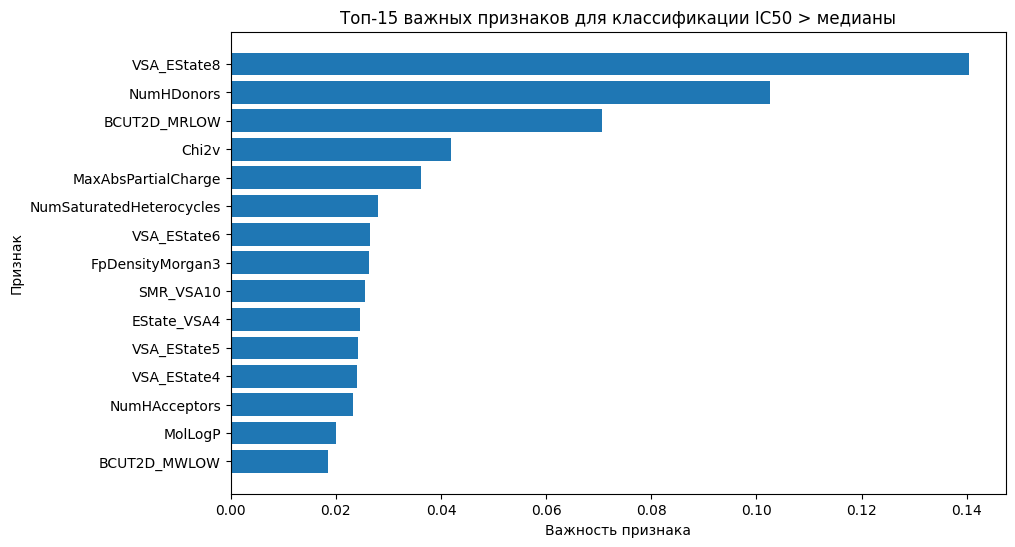

In [15]:
# 16. Визуализация важности признаков

# Берём 15 наиболее важных признаков
top_features = importance_df.head(15)

# Строим горизонтальный график важности признаков
plt.figure(figsize=(10, 6))
plt.barh(top_features['Признак'], top_features['Важность'])
plt.gca().invert_yaxis()
plt.title('Топ-15 важных признаков для классификации IC50 > медианы')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()

### Вывод по важности признаков

Для лучшей модели Gradient Boosting была рассчитана важность признаков.

Наиболее значимые признаки сильнее всего влияли на разделение соединений на два класса: `IC50, mM` выше медианы и `IC50, mM` не выше медианы.

Анализ важности признаков помогает интерпретировать работу модели и определить, какие молекулярные дескрипторы оказались наиболее полезными для классификации. При этом важность признаков не является доказательством прямой причинно-следственной связи.

### Итоговый вывод по задаче классификации IC50 > медианы

В данном ноутбуке была решена задача бинарной классификации: необходимо было определить, превышает ли значение `IC50, mM` медианное значение выборки.

Были выполнены следующие этапы:

- загружен обработанный после EDA датасет;
- удалён технический столбец `Unnamed: 0`, не являющийся химическим признаком;
- создана бинарная целевая переменная `IC50_above_median`;
- данные были разделены на обучающую и тестовую выборки с сохранением баланса классов;
- для логистической регрессии была выполнена стандартизация признаков;
- обучены и сравнены модели Logistic Regression, Random Forest и Gradient Boosting;
- выполнен подбор гиперпараметров для Gradient Boosting;
- рассчитаны метрики Accuracy, Precision, Recall, F1 и ROC-AUC;
- построена матрица ошибок и рассчитана важность признаков.

По результатам сравнения моделей лучшую метрику ROC-AUC показала модель Gradient Boosting. После подбора гиперпараметров значение ROC-AUC составило около 0.77.

Модель показывает приемлемое качество классификации и лучше случайного угадывания разделяет соединения на классы выше и ниже медианного значения `IC50, mM`.

Для дальнейшего улучшения качества можно рассмотреть более широкий подбор гиперпараметров, отбор признаков и дополнительные методы feature engineering.